In [1]:
import numpy as np
import jax.numpy as jnp
import jax.scipy as jsp
import matplotlib.pyplot as plt

from jax import random, jit, value_and_grad
from jax import config
from scipy.optimize import minimize

config.update("jax_enable_x64", True)
%matplotlib inline

In [3]:
def func(x):
    """Latent function."""
    return 1.0 * jnp.sin(x * 3 * jnp.pi) + \
           0.3 * jnp.cos(x * 9 * jnp.pi) + \
           0.5 * jnp.sin(x * 7 * jnp.pi)


# Number of training examples
n = 1000

# Noise
sigma_y = 0.2

# Noisy training data
X = jnp.linspace(-1.0, 1.0, n).reshape(-1, 1)
y = func(X) + sigma_y * random.normal(random.PRNGKey(0), shape=(n, 1))

# Test data
X_test = np.linspace(-1.5, 1.5, 1000).reshape(-1, 1)
f_true = func(X_test)

# Inducing inputs
X_m = jnp.linspace(-0.4, 0.4, m).reshape(-1, 1)

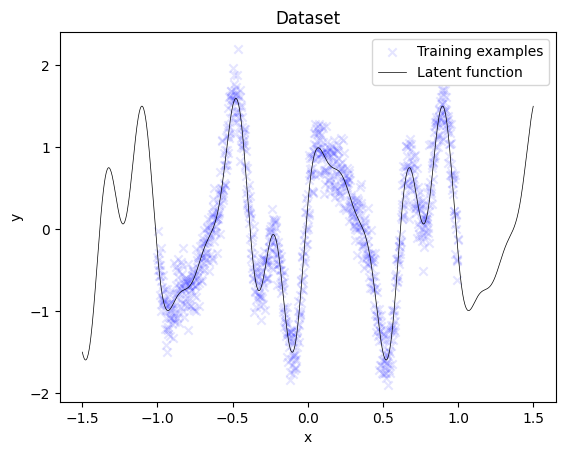

In [4]:
plt.scatter(X, y, label='Training examples', marker='x', color='blue', alpha=0.1)
plt.plot(X_test, f_true, label='Latent function', c='k', lw=0.5)
plt.title('Dataset')
plt.xlabel('x')
plt.ylabel('y')
plt.legend();

In [7]:
params = {
    "kernel":
    {
        "coefficient": jnp.array(0.9,dtype=jnp.float64),
        "log_scale":jnp.array(0.,dtype=jnp.float64)
    },
    "means":{},
    "likelihood": 
    {
        "log_diag":jnp.array(-0.5,dtype=jnp.float64)
    }
}

In [12]:
from jax_mc_pilco.model_learning.gp.kernels.stationary import ExpSquared
from jax_mc_pilco.model_learning.gp.gaussian_process import SparseGaussianProcess

ModuleNotFoundError: No module named 'kernels'